![FaMAF-UNC](https://drive.google.com/uc?export=download&id=1k4tzcXOoq6TrkDEW_Ox8o4Y4pAHzKHb7
)
> Docentes: **Damián Fernández** y **Leandro Milne**
>> Teórico del 09-04-2021


# Funciones de varias variables

## Graficando funciones

Recuerde que la clase pasada vimos que para $f: \mathbb{R}^n \to \mathbb{R}^m$ un conjunto $S$ es definido:
*  **explícitamente** si $S\subset \mathbb{R}^{n+m}$ es el gráfico de $f$, o sea $S = \operatorname{gr}(f)$,    
*  **paramétricamente** si $S\subset \mathbb{R}^{m}$ es la imagen de $f$, o sea $S = \operatorname{img}(f)$,
* **implícitamente** si $S\subset \mathbb{R}^{n}$ es un **conjunto de nivel** de $f$, o sea, para algún $\bar{y}\in\mathbb{R}^m$, $S = \{x\in \mathbb{R}^n \mid f(x) = \bar{y}\}$.





Cuando se desean estudiar curvas y superficies existen propiedades asociadas a su representación explícita, implícita y paramétrica. Veamos un ejemplo de este tipo.

#### Ejemplo

Suponga que se desea estudiar la recta $\mathcal{R} = \{ \bar{x}+ t v \in \mathbb{R}^3 \mid t \in \mathbb{R}\}$ con $v_1\neq 0$. Claramente esta curva es definida paramétricamente por la función $f:\mathbb{R} \to \mathbb{R}^3$ tal que
$$
f(t) = (\bar{x}_1 +t v_1, \bar{x}_2 + t v_2, \bar{x}_3 + t v_3).
$$
Por otro lado, tomando $s=\bar{x}_1 + t v_1$, podemos ver que $\mathcal{R}$ es definida explícitamente por $g:\mathbb{R} \to \mathbb{R}^2$ tal que
$$
g(s) = \left( \bar{x}_2 + \frac{v_2}{v_1}(s-\bar{x}_1), \bar{x}_3 + \frac{v_3}{v_1}(s-\bar{x}_1)\right).
$$
La definición implícita de $\mathcal{R}$ va a requerir escoger $u,w\in\mathbb{R}^3$ linealmente independientes y ortogonales a $v$, con esto construímos la función $h:\mathbb{R}^3 \to \mathbb{R}^2$ tal que
$$
h(x) = \bigl( \langle u, x-\bar{x} \rangle\, , \, \langle w, x-\bar{x} \rangle \bigr).
$$
Si queremos una $\tilde{h}:\mathbb{R}^3 \to \mathbb{R}$ puede ser
$$
\tilde{h}(x) = (\langle u, x-\bar{x} \rangle)^2 + (\langle w, x-\bar{x} \rangle)^2,
$$
o sea $\tilde{h}(x) = \|h(x)\|^2$.


Es simple ver que $\mathcal{R} \subset \{x\in\mathbb{R}^3 \mid h(x)=0\}$, ya que si $x=\bar{x} + t v$ entonces $h(x)=0$ por ser $u\perp v$ y $w \perp v$. Considere ahora $x$ tal que $h(x)=0$, como $u,v,w$ son linealmente independientes entonces generan $\mathbb{R}^3$, luego $x - \bar{x} = \alpha u + \beta v + \gamma w$ para $\alpha,\beta,\gamma \in \mathbb{R}$, con esto se tiene que
\begin{align*}
    0 &= \langle u, x-\bar{x} \rangle = \alpha \|u\|^2 + \gamma \langle u, w \rangle, \\
    0 &= \langle w, x-\bar{x} \rangle = \alpha \langle w, u \rangle  + \gamma \|w\|^2.
\end{align*}
Matricialmente
$$
0 = \left[\begin{array}{cc}
     \|u\|^2 & \langle u, w \rangle \\
     \langle w, u \rangle& \|w\|^2
    \end{array} \right]
    \left[\begin{array}{c}
     \alpha  \\ \gamma \end{array} \right],
$$
donde la matriz es invertible. De no serlo, su determinante es cero, o sea $\|u\|^2\|w\|^2 - \langle u, w \rangle^2 = 0$ que ocurre si y sólo si $|\langle u, w \rangle| = \|u\|\|w\|$ que vale, por la desigualdad de Cauchy-Schuarz, si y sólo si $u$ y $w$ son linealmente dependientes, contradiciendo su independencia lineal. Por lo tanto $\alpha = \gamma = 0$, con esto $x - \bar{x} =  \beta v$, o sea $\{x\in\mathbb{R}^3 \mid h(x)=0\} \subset \mathcal{R}$.

---



Veamos la deducción de una parametrización.

#### Ejemplo (cicloide)

Suponga que se desea conocer la trayectoria que realiza un punto situado en el extremo de una rueda que se desliza hacia la derecha a velocidad constante sobre una superficie plana. Consideremos que la rueda tiene radio $r$ y que en el tiempo $t=0$ el punto se encuentra a nivel del suelo. Llamemos $p(t)$ al punto en cuestión, el movimiento que este realiza podemos descomponerlo como suma de un movimiento de rotación $\gamma(t)$ alrededor del eje y otro de traslación del eje $\tau(t)$.


In [ ]:
#@title Cicloide { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import matplotlib.animation as animation

from matplotlib import rc
rc('animation', html='jshtml')

fig = plt.figure(figsize=plt.figaspect(0.5))
ax1 = fig.add_subplot(2,1,1)
ax2 = fig.add_subplot(2,1,2)
plt.close()

r = 1
r0 = 0.7*r
th = np.linspace(0,2*np.pi,200)
circulo = np.array([r*np.cos(th), r*np.sin(th)])
l = np.linspace(0,4*np.pi,200)
cicloide = np.array([r*(l - np.sin(l)), r*(1-np.cos(l))])
#t = 3*np.pi/4
def animacion(t):
  ax1.clear()
  ax2.clear()

  ax1.plot(circulo[0], circulo[1], color='b')
  ax1.plot([-1.2*r,1.2*r], [0,0], color=(0.5,0.5,0.5))
  ax1.plot([0,0],[-1.2*r,1.2*r], color=(0.5,0.5,0.5))

  th0 = np.arange(0,t%(2*np.pi),np.pi/100)
  tmp = 3*np.pi/2-th0[-1]
  ss = 2*(tmp>=0)-1
  th1 = np.arange(0,tmp,ss*np.pi/100)
  ax1.plot(-r0*np.sin(th0), -r0*np.cos(th0),color='k')
  ax1.arrow(-r0*np.sin(th0[-1]-0.3),-r0*np.cos(th0[-1]-0.3),-r0*(np.sin(th0[-1])-np.sin(th0[-1]-0.3)),-r0*(np.cos(th0[-1])-np.cos(th0[-1]-0.3)),length_includes_head=True,head_width=0.08, head_length=0.2,color='k')
  ax1.text(-1.2*r0*np.sin(th0[-1]-0.3),-1.2*r0*np.cos(th0[-1]-0.3),'$t$',fontsize=14,verticalalignment='center',horizontalalignment='center')
  ax1.plot(0.7*r0*np.cos(th1), 0.7*r0*np.sin(th1),color='k')
  ax1.arrow(0.7*r0*np.cos(th1[-1]-0.3),0.7*r0*np.sin(th1[-1]-0.3),0.7*r0*(np.cos(th1[-1])-np.cos(th1[-1]-0.3)),0.7*r0*(np.sin(th1[-1])-np.sin(th1[-1]-0.3)),length_includes_head=True,head_width=0.08, head_length=0.2,color='k')
  ax1.text(r0,0,r'$\frac{3\pi}{2}-t$',fontsize=14,verticalalignment='bottom',horizontalalignment='left')
  ax1.plot([0,r*np.cos(th1[-1])], [0,r*np.sin(th1[-1])], color='b')
  gamma = r*np.array([np.cos(th1[-1]),np.sin(th1[-1])])
  ax1.plot(gamma[0], gamma[1], 'ro')
  ax1.text(1.3*gamma[0], 1.3*gamma[1], r'$\gamma(t)$', fontsize=14)
  ax1.axis('equal')
  ax1.axis('off')

  ax2.plot(cicloide[0], cicloide[1], color='g')
  ax2.plot([-1.1*r,1.1*l[-1]], [0,0], color=(0.5,0.5,0.5))
  ax2.plot([0,0],[-0.1,1.1*2*r], color=(0.5,0.5,0.5))
  tau = r*np.array([t,1])
  pt = tau + gamma
  ax2.plot(tau[0]+circulo[0], tau[1]+circulo[1],color='b')
  ax2.axis('equal')
  plot = ax2.plot(pt[0], pt[1], 'ro')
  return plot

anim = animation.FuncAnimation(fig, animacion, frames=np.arange(0.032,4*np.pi,np.pi/52), repeat = False)

anim
#plt.savefig('ejm_cicloide.pdf')

Si analizamos la rotación, nuestro punto comienza en el ángulo $3\pi/2$ y gira en el sentido de las agujas del reloj, por lo tanto
\begin{align*}
    \gamma(t) &= \left(r \cos\bigl({\textstyle \frac{3\pi}{2}} -t \bigr), r \operatorname{sen}\bigl({\textstyle \frac{3\pi}{2}} -t \bigr)\right) \\      &= \left(-r \operatorname{sen}(t), -r \cos(t) \right).  
\end{align*}
Por otro lado, el eje tiene una altura fija igual al radio y se traslada hacia la derecha la misma longitud que el el recorrido de la rueda, o sea
$$
\tau(t) = ( r t, r).
$$
Obteniendo así que la trayectoria del punto en cuestión es
$$
p(t) = \gamma(t) + \tau(t) = \bigl( r(t-\operatorname{sen}(t)), r(1-\cos(t))\bigr).
$$
Esta curva es conocida como **cicloide**.

---



Cuando el espacio dominio y el espacio imagen tienen la misma dimensión (o sea, es un campo vectorial) y la función estudiada retorna el movimiento asociado a cada punto del dominio, una representación gráfica muy utilizada es la de un campo de vectores con flechas que salen de un punto con dirección y magnitud dada por el valor de la función.

#### Ejemplo

Considere la función $f:\mathbb{R}^2 \to \mathbb{R}^2$ tal que
$$
f(x) = \left(-\frac{x_2}{\sqrt{x_1^2 + x_2^2}}, \frac{x_1}{\sqrt{x_1^2 + x_2^2}} \right).
$$



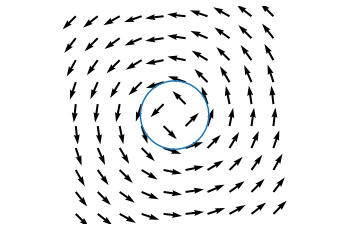

In [ ]:
#@title Campo vectorial { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

x,y = np.meshgrid(np.linspace(-5,5,10),np.linspace(-5,5,10))

u = -y/np.sqrt(x**2 + y**2)
v = x/np.sqrt(x**2 + y**2)
th = np.linspace(0,2*np.pi,200)
r = 1.73
plt.plot(r*np.cos(th),r*np.sin(th))
plt.quiver(x,y,u,v)
plt.axis('equal')
plt.axis('off');
#plt.savefig('ejm_campoVec.pdf')

Este campo rota el plano en sentido contrario a las agujas del reloj.

---


## Límites y continuidad

Para poder extender las nociones de límite y de continudad a funciones de varias variables, es necesario primero entender los conceptos básicos de topología.

### Topología del espacio Euclídeo

En un espacio Euclídeo, la noción de proximidad puede estudiarse mediante el uso del conjunto
$$
B_r(x) = \{ y\in \mathbb{R}^n \mid \|y-x\| < r\},
$$
donde $r>0$, que llamaremos bola abierta de centro $x$ y radio $r$.
Cuando $n=1$ se tiene que $B_r(x) = (x-r, x+r)$ y se conoce como intervalo abierto. Cuando $n=2$ se tiene que $B_r(x) = \{\bigl(x_1 + \rho \cos(\theta), x_2 + \rho \operatorname{sen}(\theta) \bigr) \mid 0 \leq \theta \leq 2\pi, \, 0\leq \rho < r \}$ y se conoce como disco abierto.


Para poder introducir la noción de conjunto abierto, necesitaremos lo siguiente.

>**Definición**
>
> Diremos que $x$ es un **punto interior** de $S\subset \mathbb{R}^n$ si existe $r>0$ tal que
$$
B_r(x) \subset S.
$$
El conjunto de puntos interiores de un conjunto $S$ se llama **interior** de $S$ y lo denotaremos por $\operatorname{int}(S)$ (también denotado por $S^\circ$). Cuando $x\in \operatorname{int}(S)$ se dice que $S$ es un **entorno** de $x$.


Note que para que $x$ sea punto interior de un conjunto entonces todos los puntos suficientemente próximos a $x$ también deben estar en el conjunto.


---

#### Ejemplo

Sea $S=\{x\in\mathbb{R}^2 \mid x_2\geq 0\}$. Si $p\in S$ con $p_2>0$, tomo $r=p_2$ y $x\in B_r(p)$ arbitrario, entonces
$$
|x_2 - p_2| \leq \sqrt{(x_1 - p_1)^2 + (x_2-p_2)^2} = \|x-p\| < r = p_2.
$$
Luego $-p_2 < x_2 - p_2$ y por lo tanto $x_2>0$. Con esto, $x\in S$. Demostrando que $B_r(p) \subset S$. Por lo tanto $p \in \operatorname{int}(S)$.

Si $q\in S$ con $q_2=0$, entonces $q \notin \operatorname{int}(S)$. Pues para cualquier $r>0$ tomamos $x=(q_1, -r/2)$ que no pertenece a $S$ pero pertenece a $B_r(q)$, ya que
$$
\|x-q\| = \sqrt{(x_1 - q_1)^2 + (x_2 - q_2)^2} = |-r/2| = r/2 < r.
$$
Concluyendo que $B_r(q) \not\subset S$ para cualquier $r>0$.

---



>**Definición**
>
> Diremos que $U \subset \mathbb{R}^n$ es un conjunto **abierto** si todos sus puntos son interiores, o sea, $U = \operatorname{int}(U)$.


Claramente, $\mathbb{R}^n$ es abierto. Por convención, el conjunto vacío $\emptyset$ también se considerará un abierto.



---

#### Ejemplo

Veamos que $B_r(x)$ es un conjunto abierto. Sea $y\in B_r(x)$, entonces $s = r - \|y-x\| > 0$ y para $z\in B_s(y)$ tenemos que
$$
    \|z-x \| \leq \|z-y\| + \|y-x\| < s + \|y-x\| = r.
$$
Por lo tanto $B_s(y) \subset B_r(x)$. Luego $\operatorname{int}(B_r(x)) = B_r(x)$.

---


>**Teorema**
>
> Los abiertos cumplen las siguientes propiedades:
1. Si $\{ U_\lambda\}_{\lambda \in \Lambda}$ es una familia arbitraria de conjuntos abiertos $U_\lambda \subset \mathbb{R}^n$, entonces la unión
    $$
    \bigcup_{\lambda \in \Lambda} U_\lambda,
    $$
    es un conjunto abierto.
2. Si $U_1$ y $U_2$ son abiertos, entonces $U_1 \cap U_2$ es abierto.

**Demostración:**
Para probar (1), considere un elemento arbitrario $x\in \bigcup_{\lambda \in \Lambda} U_\lambda$, luego $x\in U_{\bar\lambda}$ para algún $\bar\lambda \in \Lambda$. Como $U_{\bar\lambda}$ es abierto entonces existe $r>0$ tal que
$$
B_r(x) \subset U_{\bar\lambda} \subset \bigcup_{\lambda \in \Lambda} U_\lambda.
$$
Demostrando que todo $x$ es un punto interior.

Para ver (2), considere un elemento arbitrario $x\in U_1 \cap U_2$.  Como $x\in U_1$ y $x\in U_2$, al ser ambos abiertos existen $r_1>0$ y $r_2>0$ tal que $B_{r_1}(x) \subset U_1$ y $B_{r_2}(x) \subset U_2$. Tomando $r=\min\{r_1, r_2\}$ obtenemos que $B_{r}(x) \subset U_1$ y $B_{r}(x) \subset U_2$, luego
$$
B_{r}(x) \subset U_1 \cap U_2.
$$
Concluyendo que todo $U_1 \cap U_2$ es abierto. $\spadesuit$


Claramente, repitiendo el argumento del ítem 2 se puede obtener que la intersección de un número finito de conjuntos abiertos $U_1 \cap U_2 \cap \ldots \cap U_k$ es un conjunto abierto. Es importante resaltar que, a diferencia de la unión, la intersección infinita de abiertos puede no ser un abierto. Por ejemplo, note que
$$
\bigcap_{k=1}^\infty B_{1/k}(x) = \{x\},
$$
no es un conjunto abierto.


Ahora introduciremos la noción de conjunto cerrado.

>**Definición**
>
> Diremos que $x$ es un **punto de acumulación** (o punto límite) de $S\subset \mathbb{R}^n$ si para todo $r>0$ vale que
$$
    \left( B_r(x)\setminus\{x\}\right) \cap S \neq \emptyset.
$$
Un punto $x\in S$ que no es un punto de acumulación es llamado **punto aislado**. El conjunto formado por los puntos aislados y puntos de acumulación de $S$ se llama **clausura** (o cierre) de $S$ y lo denotaremos por $\operatorname{cl}(S)$ (también denotado por $\bar{S}$).



Desde otra perspectiva, los puntos de acumulación son aquellos puntos a los cuales se puede llegar tan cerca como uno quiera desde puntos en $S$.
Se puede ver que de manera equivalente, $x$ es un punto aislado de $S$ si existe $r>0$ tal que $B_r(x) \cap S = \{x\}$. Con esto, note que los puntos no aislados de $S$ deben ser puntos de acumulación. De esta forma $\operatorname{cl}(S)$ es la unión de $S$ con sus puntos de acumulación.



---

#### Ejemplo

Veamos que $\operatorname{cl}\bigl( B_r(x)\bigr) = \{y \in \mathbb{R}^n \mid \|y-x \|\leq r\}$ probando las dos inclusiones.



$(\supset)$. Tome $y$ en el conjunto de la derecha, o sea $\|y-x\| \leq r$. Dado $s>0$, si $y=x$ claramente $\bigl(B_s(y)\setminus\{y\} \bigr) \cap B_r(x) \neq \emptyset$. Si $y\neq x$ considere $z= x+ \alpha (y-x)$ con $\alpha = r/(r+s)$, usando que $\alpha \in (0,1)$ se obtiene que
$$
    \|z-x\| = \alpha \|y-x\| \leq \alpha r < r,
$$
o sea, $z\in B_r(x)$. Por otro lado,
$$
    \|z-y\| = (1-\alpha) \|x-y\| = \frac{s}{r+s} \|x-y\| \leq \frac{r}{r+s} s < s,
$$
y claramente $\|z-y\|>0$. Obteniendo que $z\in B_s(y) \setminus\{y\}$. En consecuencia $z\in \bigl(B_s(y)\setminus\{y\} \bigr) \cap B_r(x)$. Concluyendo que $y$ es un punto de acumulación.


$(\subset)$. Suponga que $y$ no pertenece al conjunto de la derecha, o sea $\|y-x\|>r$. Tomando $s=\|y-x\| -r$, para cualquier $z\in B_s(y)$, usando que $\|y-x\| \leq \|y-z\| + \|z-x\|$, se tiene que
$$
    \|z-x\| \geq \|y-x\| - \|z-y\| > \|y-x\| - s = r.
$$
Obteniendo que $y$ no es un punto de acumulación de $B_r(x)$, pues existe $s>0$ tal que $B_s(y)\setminus\{y\} \cap B_r(x) = \emptyset$. Además, como $y\notin B_r(x)$, concluímos que $y\notin \operatorname{cl}\bigl( B_r(x)\bigr)$.


---


Continuara...
----